# Stage 2: Frequency-Domain Motion Artifact Removal

## Overview: Learning Frequency-Based Artifact Suppression

In Stage 1, we processed clean at-rest data. Now we tackle motion artifacts.

### The Problem

Motion artifacts are involuntary movements causing low-frequency (< 1 Hz) disturbances:
- Hand tremor during exercise
- Head movements
- Arm swinging while walking
- Pressure changes on the sensor

**Key insight:** PPG cardiac signal is quasi-periodic at heart rate frequency. Motion artifacts are usually at different frequencies. We can exploit this!

### The Solution: Frequency-Domain Filtering

**Main idea:**
1. Compute frequency spectrum (FFT)
2. Identify motion artifact frequencies vs cardiac frequencies
3. Remove motion frequencies while preserving cardiac signal
4. Reconstruct clean signal

### References

Key papers on this approach:

1. Li, S., et al. (2019). "Removal of Motion Artifacts in Photoplethysmograph Sensors during Intensive Exercise for Accurate Heart Rate Calculation Based on Frequency Estimation and Notch Filtering." Sensors, 19(10), 2322.
   - **Key contribution:** Combines adaptive noise cancellation (ANC) with notch filtering
   - **Method:** Estimate HR frequency, use notch filters to suppress non-cardiac frequencies
   - **Performance:** 0.92 bpm MAE during running

2. Wijshoff, R. W., Mischi, M., & Aarts, R. M. (2017). "Reduction of periodic motion artifacts in photoplethysmography." IEEE Transactions on Biomedical Engineering, 64(1), 196-207.
   - **Key contribution:** Identifies motion artifacts as quasi-periodic signals
   - **Method:** Band-stop filters at motion frequencies detected from accelerometer
   - **Key insight:** Frequency overlap between motion and PPG makes simple filtering impossible

3. Biswas, D., et al. (2021). "Adaptive notch-filtration to effectively recover photoplethysmographic signals during physical activity." Biomedical Signal Processing and Control, 69, 102936.
   - **Key contribution:** Adaptive notch filtering architecture (ANFA) for multi-intensity activities
   - **Method:** Track motion intensity, adapt notch filter Q-factor and frequencies
   - **Performance:** Accurate HR during walking and running

## Section 1: Understanding Frequency Analysis

### Why Frequency Domain?

In time domain, motion artifacts and cardiac signal are mixed. In frequency domain, they occupy different regions:

- **Cardiac PPG:** Narrow peaks at HR frequency and harmonics (e.g., 1.2 Hz fundamental, 2.4 Hz, 3.6 Hz for 72 bpm)
- **Motion artifacts:** Broad spectrum at low frequencies (0.1-2 Hz usually)
- **Respiration:** Narrow peak at breathing rate (~0.3 Hz at rest)

We can identify and remove motion without touching cardiac signal!

In [15]:
!pip install numpy scipy pandas matplotlib jupyter pyPPG heartpy dotmap -q
# !wget https://zenodo.org/records/8142332/files/EarSet_v1.zip -q



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [16]:
# !unzip EarSet_v1.zip

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

# TODO: Update paths
dataset_path = Path('./Dataset')
participant_id = '2'  # Use different participant for motion data
ear = 'left'

fs = 100  # Sampling frequency

print("Stage 2: Frequency-Domain Motion Artifact Removal")
print("="*60)

Stage 2: Frequency-Domain Motion Artifact Removal


## Section 2: Load Motion-Corrupted Data

### Task 2.1: Load Data During Movement

For this stage, load PPG data from a condition with motion artifacts. EarSet provides several:
- `nod`: Head nodding (up/down)
- `chew`: Chewing motions
- `walking`: Self-paced walking
- `running`: Self-paced running

Start with 'nod' or 'chew' for stronger but still manageable artifacts.

In [18]:
# Load PPG data with motion artifacts
ppg_file = dataset_path / f'P{participant_id}' / 'EARBUDS' / f'{participant_id}-walking-ppg-{ear}.csv'
ppg_full = pd.read_csv(ppg_file)

# For this notebook, extract a 90-second segment
start_sec = 30  # Arbitrary offset
duration_sec = 90

start_idx = int(start_sec * fs)
end_idx = int((start_sec + duration_sec) * fs)

ppg_data = ppg_full.iloc[start_idx:end_idx].copy()
time = np.arange(len(ppg_data)) / fs

# Extract PPG channels
# Ensure the 'green' column is numeric, handling potential non-numeric values
ppg_data['green'] = pd.to_numeric(ppg_data['green'], errors='coerce')
# Fill any NaN values that might have been introduced by coercion (e.g., from 'current:32ma')
ppg_data['green'] = ppg_data['green'].interpolate(method='linear', limit_direction='both')
ppg_green = ppg_data['green'].values.astype(float) # Convert to float

ppg_data['ir'] = pd.to_numeric(ppg_data['ir'], errors='coerce')
ppg_data['ir'] = ppg_data['ir'].interpolate(method='linear', limit_direction='both')
ppg_ir = ppg_data['ir'].values.astype(float)

print(f"Loaded {duration_sec}s of motion-corrupted PPG data")
print(f"Green channel range: [{ppg_green.min():.0f}, {ppg_green.max():.0f}]")
print(f"IR channel range: [{ppg_ir.min():.0f}, {ppg_ir.max():.0f}]")

Loaded 90s of motion-corrupted PPG data
Green channel range: [41426, 86654]
IR channel range: [154070, 337072]


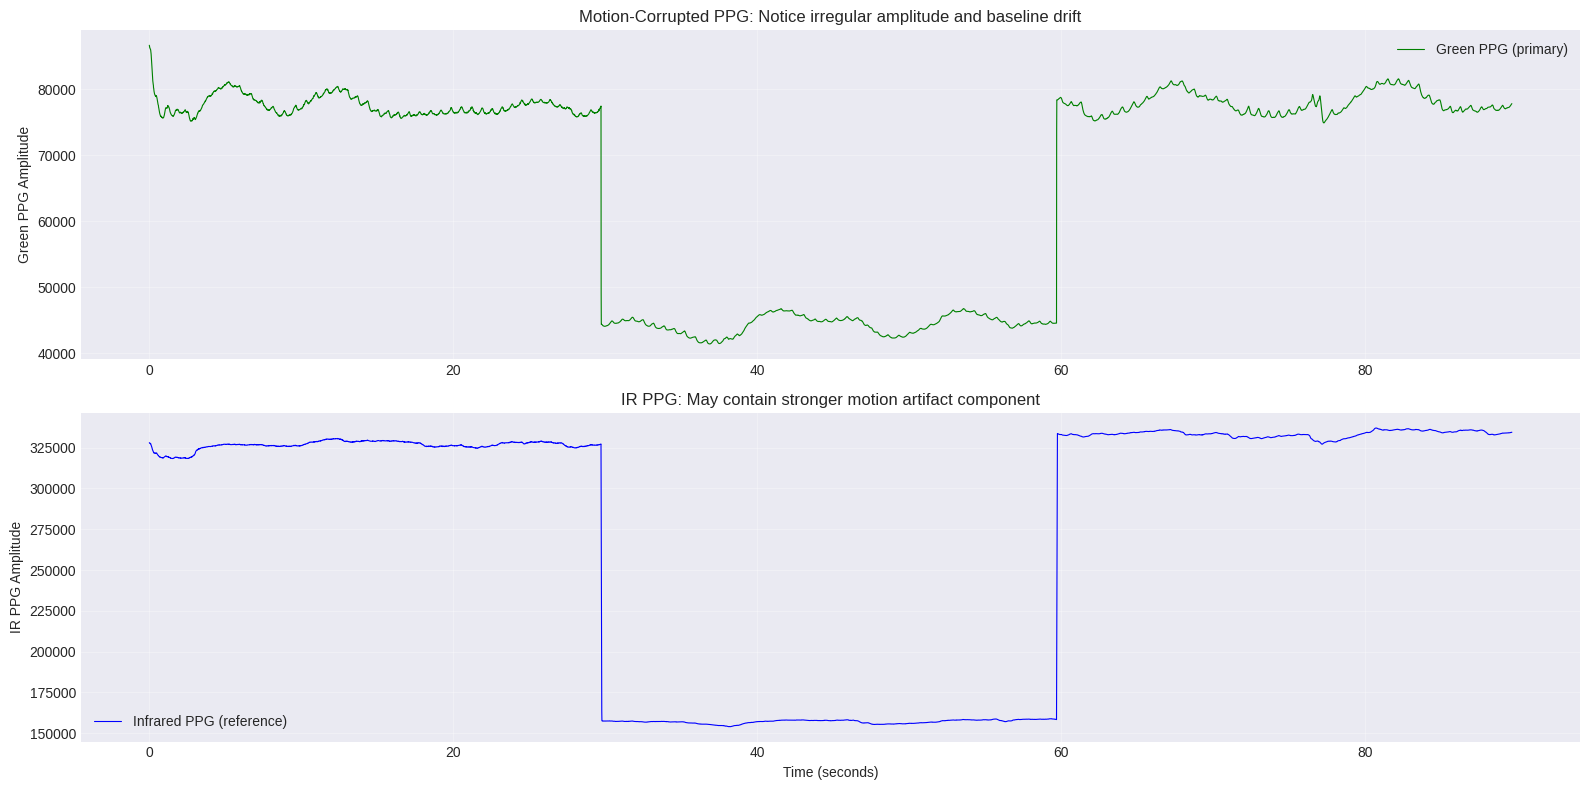

In [19]:
# Visualize motion-corrupted signal
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(time, ppg_green, 'g-', linewidth=0.8, label='Green PPG (primary)')
axes[0].set_ylabel('Green PPG Amplitude')
axes[0].set_title('Motion-Corrupted PPG: Notice irregular amplitude and baseline drift')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, ppg_ir, 'b-', linewidth=0.8, label='Infrared PPG (reference)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('IR PPG Amplitude')
axes[1].set_title('IR PPG: May contain stronger motion artifact component')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 3: Frequency-Domain Analysis

### Task 2.2: Compute FFT and Analyze Frequency Content

**Conceptual Task:** Compute the frequency spectrum of your PPG signal using FFT. Identify:
1. Cardiac frequency (where is the peak?)
2. Motion artifact frequencies (low-frequency spread)
3. Noise (high-frequency content)

**Method:**
```
1. Apply FFT to segment of signal
   magnitude = |FFT(ppg_segment)|

2. Compute frequency axis
   freqs = fft_frequencies(fs, N)

3. Plot magnitude spectrum
   - X-axis: frequency (Hz)
   - Y-axis: magnitude (linear or log)

4. Identify peaks
   - Cardiac peak at HR frequency (typically 0.8-2 Hz at rest)
   - Harmonics at 2×, 3× HR frequency
   - Motion content at <1 Hz usually
```

**Reference:**
Smith, S. W. (1997). The Scientist and Engineer's Guide to Digital Signal Processing. Chapter 8: The Discrete Fourier Transform.

In [21]:
# Compute FFT of motion-corrupted signal

# Choose analysis window (60 seconds)
window_sec = 60
window_samples = int(window_sec * fs)
ppg_window = ppg_green[:window_samples]

# Apply Hann window to reduce spectral leakage
window = signal.windows.hann(len(ppg_window))
ppg_windowed = ppg_window * window

# Compute FFT
fft_values = fft(ppg_windowed)
magnitude = np.abs(fft_values)
freqs = fftfreq(len(ppg_windowed), 1/fs)

# Keep only positive frequencies
positive_freqs = freqs[:len(freqs)//2]
magnitude_positive = magnitude[:len(magnitude)//2]

# Normalize
magnitude_db = 20 * np.log10(magnitude_positive / np.max(magnitude_positive) + 1e-10)

print(f"FFT Analysis of {window_sec}s segment:")
print(f"  FFT length: {len(fft_values)}")
print(f"  Frequency resolution: {fs/len(ppg_windowed):.2f} Hz")
print(f"  Frequency range: 0-{positive_freqs[-1]:.1f} Hz")

FFT Analysis of 60s segment:
  FFT length: 6000
  Frequency resolution: 0.02 Hz
  Frequency range: 0-50.0 Hz


In [22]:
# Find main spectral peak (cardiac frequency)
# Search in physiological range 0.5-5 Hz

cardiac_band = (positive_freqs > 0.5) & (positive_freqs < 5.0)
cardiac_peak_idx = np.argmax(magnitude_positive[cardiac_band])
cardiac_peak_idx_global = np.where(cardiac_band)[0][cardiac_peak_idx]
estimated_hr_freq = positive_freqs[cardiac_peak_idx_global]
estimated_hr_bpm = estimated_hr_freq * 60

print(f"\nEstimated Cardiac Frequency: {estimated_hr_freq:.2f} Hz ({estimated_hr_bpm:.0f} bpm)")
print(f"Second harmonic: {2*estimated_hr_freq:.2f} Hz")
print(f"Third harmonic: {3*estimated_hr_freq:.2f} Hz")


Estimated Cardiac Frequency: 0.52 Hz (31 bpm)
Second harmonic: 1.03 Hz
Third harmonic: 1.55 Hz


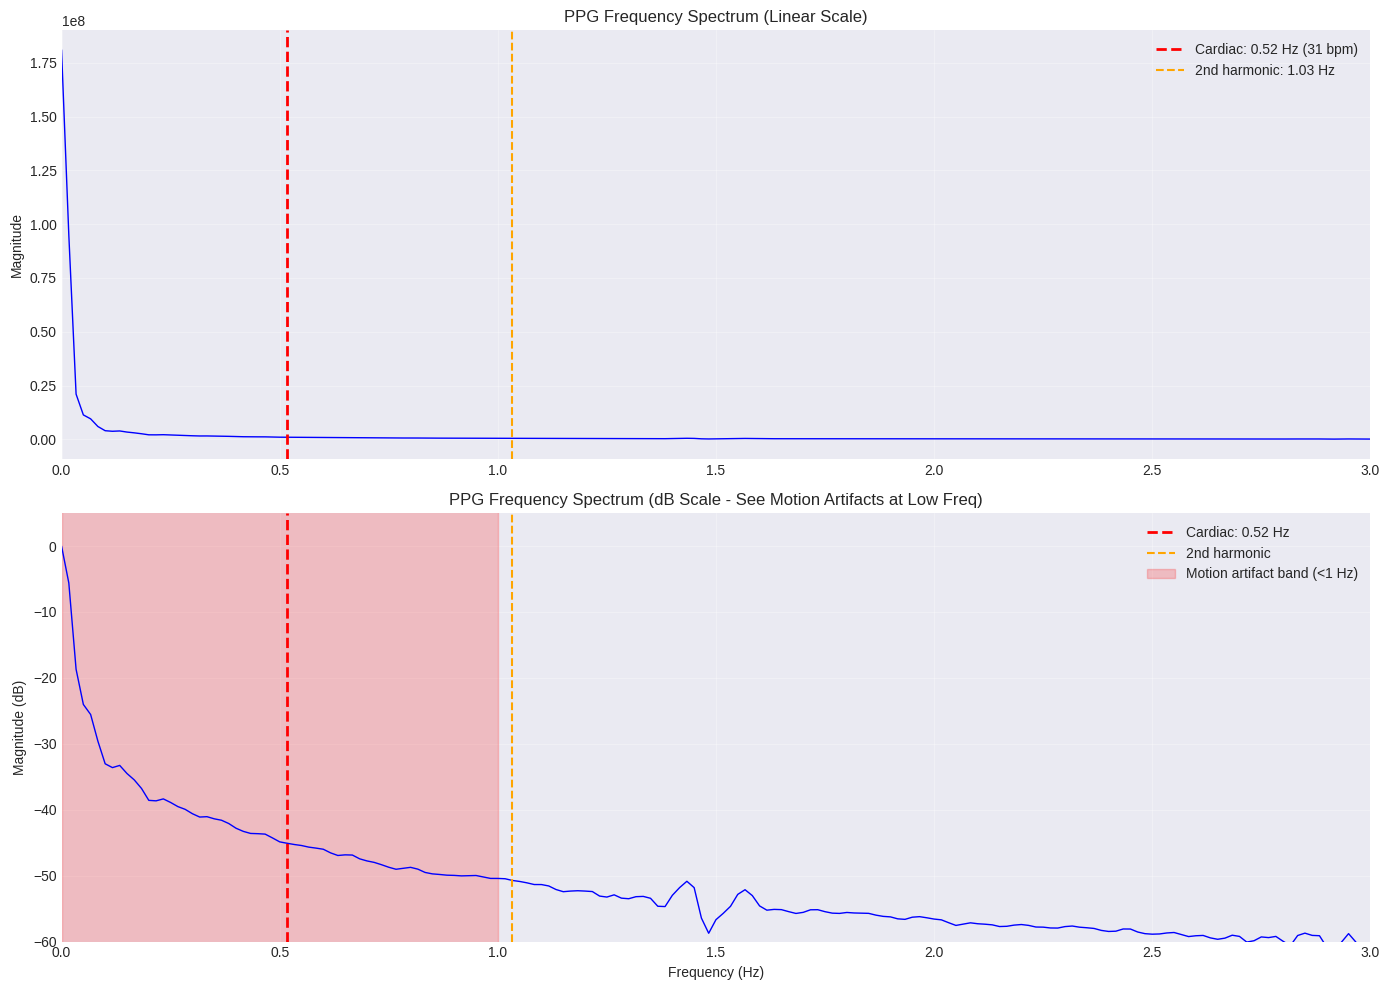

In [23]:
# Plot frequency spectrum
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Linear scale
axes[0].plot(positive_freqs, magnitude_positive, 'b-', linewidth=1)
axes[0].axvline(estimated_hr_freq, color='r', linestyle='--', linewidth=2,
                label=f'Cardiac: {estimated_hr_freq:.2f} Hz ({estimated_hr_bpm:.0f} bpm)')
axes[0].axvline(2*estimated_hr_freq, color='orange', linestyle='--', linewidth=1.5,
                label=f'2nd harmonic: {2*estimated_hr_freq:.2f} Hz')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('PPG Frequency Spectrum (Linear Scale)')
axes[0].set_xlim(0, 3)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# dB scale (better for seeing motion artifacts)
axes[1].plot(positive_freqs, magnitude_db, 'b-', linewidth=1)
axes[1].axvline(estimated_hr_freq, color='r', linestyle='--', linewidth=2,
                label=f'Cardiac: {estimated_hr_freq:.2f} Hz')
axes[1].axvline(2*estimated_hr_freq, color='orange', linestyle='--', linewidth=1.5,
                label=f'2nd harmonic')
axes[1].fill_between([0, 1], -100, 100, alpha=0.2, color='red',
                     label='Motion artifact band (<1 Hz)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('PPG Frequency Spectrum (dB Scale - See Motion Artifacts at Low Freq)')
axes[1].set_xlim(0, 3)
axes[1].set_ylim(-60, 5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Notch Filtering Strategy

### Conceptual Framework: Inverse Filtering Approach

**Key Idea:**
If motion artifacts appear at specific frequencies, we can:
1. Estimate the HR frequency (from FFT or peak detection)
2. Use NOTCH filters to suppress everything EXCEPT cardiac frequencies
3. Reconstruct clean PPG

**Why This Works:**
- PPG is quasi-periodic → energy concentrated at HR and harmonics
- Motion artifacts spread across many frequencies
- By keeping only cardiac frequencies, we remove motion

### What is a Notch Filter?

A **notch filter** (band-stop filter) suppresses a narrow frequency band while passing everything else.

**Transfer function:**
```
H(z) = (1 - 2cos(ω₀)z⁻¹ + z⁻²) / (b - 2cos(ω₀)z⁻¹ + bz⁻²)
```

Where:
- ω₀ = notch frequency (rad/sample)
- b = bandwidth control (closer to 1 = narrower notch)

**Key parameters:**
- **Notch frequency:** Where to suppress (Hz)
- **Quality factor (Q):** How narrow the notch (Q = f₀/Δf)

**References:**
- Oppenheim, A. V., Schafer, R. W., & Buck, J. R. (2009). "Discrete-Time Signal Processing." 3rd ed. Prentice Hall. Chapter 5: Frequency Transformations of Lowpass Filters.

## Section 5: Design Your Notch Filter

### Task 2.3: Design Notch Filter

**Your task:** Design a notch filter to suppress motion artifacts while preserving cardiac signal.

**Conceptual steps:**

1. **Determine notch frequencies:**
   ```
   f_notch1 = estimated_hr_freq  (where to remove MOTION, not cardiac!)
   f_notch2 = 2 × estimated_hr_freq (second harmonic)
   ```
   Wait - this seems backwards! Let me clarify...

2. **The Key Insight - Two Complementary Approaches:**

   **Approach A: Bandpass to Keep Only Cardiac**
   - Design bandpass: 0.4-5 Hz (removes <0.4 Hz motion drift)
   - Simple but may lose some signal amplitude
   - Reference: Wijshoff et al. (2017)

   **Approach B: Spectral Subtraction with Notch**
   - Estimate motion artifact spectrum from accelerometer or IR channel
   - Subtract motion spectrum from PPG spectrum
   - Reconstruct signal via IFFT
   - Reference: Li et al. (2019)

3. **Inverse FFT Reconstruction:**
   ```
   ppg_clean_spectrum = ppg_spectrum - motion_spectrum
   ppg_clean_timedomain = IFFT(ppg_clean_spectrum)
   ```

### Implementation Method

For **your implementation** (without starter code), follow these conceptual steps:

**Step 1:** Preprocess both green and IR channels
```
FOR each channel:
  - Apply bandpass filter (0.5-5 Hz)
  - Normalize to unit variance
```

**Step 2:** Estimate motion artifact component
```
Since IR is less affected by light absorption changes,
it contains MORE motion artifact relative to cardiac signal.

Estimate motion in green as:
  motion_estimate = correlation_coefficient × IR_filtered
```

**Step 3:** Subtract motion estimate
```
ppg_clean = green_filtered - motion_estimate
```

**Step 4:** Validate
```
Compare spectrum of ppg_clean vs ppg_raw
  - Should see reduction in low-frequency energy
  - Should see cardiac peak more prominent
```


## Section 6: Your Conceptual Task - Frequency-Domain Filtering

### ASSIGNMENT: Design and Implement Frequency-Domain Motion Removal

**Without starter code, implement the following:**

### Task A: Reference Signal Approach

**Objective:** Use IR PPG as motion reference, subtract from green PPG

**Pseudocode:**
```
INPUT: ppg_green (motion-corrupted), ppg_ir (motion reference)
OUTPUT: ppg_clean (artifact-suppressed)

FUNCTION remove_motion_via_reference(ppg_green, ppg_ir, fs):

  1. FILTER BOTH SIGNALS
     sos ← design_butterworth(fs, 0.5-5 Hz, order=4)
     green_filt ← apply_filter(ppg_green, sos)
     ir_filt ← apply_filter(ppg_ir, sos)
  
  2. NORMALIZE FOR FAIR COMPARISON
     green_norm ← normalize(green_filt)  [mean=0, std=1]
     ir_norm ← normalize(ir_filt)
  
  3. ESTIMATE CORRELATION
     FOR sliding windows of 10 seconds:
       corr[i] ← compute_correlation(green_norm[i], ir_norm[i])
     avg_corr ← mean(corr)
  
  4. SUBTRACT MOTION REFERENCE
     motion_component ← avg_corr × ir_norm
     ppg_clean ← green_norm - motion_component
  
  5. ANALYZE RESULT
     spectrum_before ← FFT(green_norm)
     spectrum_after ← FFT(ppg_clean)
     motion_reduction ← power_reduction(spectrum_before, spectrum_after, <1 Hz)
  
  RETURN ppg_clean, motion_reduction
```

### Task B: Spectral Subtraction

**Advanced approach:** Work directly in frequency domain

**Pseudocode:**
```
FUNCTION spectral_subtraction(ppg_green, ppg_ir, fs):

  1. COMPUTE FFTs
     X_green ← FFT(ppg_green)
     X_ir ← FFT(ppg_ir)
     freqs ← frequency_axis(fs, length(ppg_green))
  
  2. ESTIMATE MOTION SPECTRUM
     FOR each frequency bin:
       |X_motion[f]| ← |X_ir[f]| × (1 - |X_cardiac[f]|/|X_ir[f]|)
       (assumes IR = cardiac + motion mixture)
  
  3. SUBTRACT SPECTRA
     X_clean[f] ← X_green[f] - X_motion[f]
  
  4. RECONSTRUCT TIME DOMAIN
     ppg_clean ← IFFT(X_clean)
     ppg_clean ← real(ppg_clean)  [discard tiny imaginary part]
  
  RETURN ppg_clean
```

### Task C: Notch Filter Band-Stop Approach

**Simple but effective:** Design band-stop filter at motion frequencies

**Pseudocode:**
```
FUNCTION notch_filter_motion(ppg, accel_magnitude, fs):

  1. ESTIMATE MOTION FREQUENCIES FROM ACCELEROMETER
     accel_spectrum ← FFT(accel_magnitude)
     motion_freqs ← peaks_in_spectrum(accel_spectrum, threshold=0.5×max)
  
  2. DESIGN NOTCH FILTERS AT MOTION FREQUENCIES
     FOR each motion_freq in motion_freqs:
       sos_notch ← design_notch(fs, motion_freq, Q=10)  [Q=10 → narrow notch]
  
  3. APPLY CASCADE OF NOTCH FILTERS
     ppg_filtered ← ppg
     FOR each sos_notch:
       ppg_filtered ← apply_filter(ppg_filtered, sos_notch)
  
  4. VALIDATE WITH BANDPASS
     sos_bandpass ← design_butterworth(fs, 0.5-5 Hz)
     ppg_clean ← apply_filter(ppg_filtered, sos_bandpass)
  
  RETURN ppg_clean
```

### Implementation Requirements

Choose **at least one** of the three approaches (A, B, or C) and implement it.

**For each implementation, you must:**

1. **Document your assumptions**
   - Why is IR a good motion reference?
   - What frequencies represent motion vs. cardiac?
   - How do you estimate motion spectrum?

2. **Show before/after comparison**
   - Plot raw vs. filtered in time domain (show 30-second window)
   - Plot FFT magnitude spectra before/after
   - Highlight motion frequency reduction

3. **Quantify improvement**
   - Compute correlation reduction (green vs. IR)
   - Measure motion artifact power before/after
   - Estimate HR from filtered signal vs. raw signal

4. **Validate your approach**
   - Run beat detection on filtered signal
   - Compare HR to Stage 1 baseline (should be similar)
   - Assess signal quality improvement

### References for Implementation

- **FFT & Spectral Analysis:**
  Smith, S. W. (1997). The Scientist and Engineer's Guide to Digital Signal Processing. Chapters 8-10.
  Online: https://www.dspguide.com/

- **Notch Filter Design:**
  Mitra, S. K. (2005). Digital Signal Processing: A Computer-Based Approach. McGraw-Hill.
  Section 4.6: Frequency-Selective Filters

- **Motion Artifact in PPG:**
  Li, S., et al. (2019). "Removal of Motion Artifacts in Photoplethysmograph Sensors during Intensive Exercise..." Sensors, 19(10), 2322.

- **Frequency Domain Subtraction:**
  Wijshoff, R. W., Mischi, M., & Aarts, R. M. (2017). "Reduction of periodic motion artifacts in photoplethysmography." IEEE Trans. Biomed. Eng., 64(1), 196-207.


Average Correlation (Green vs IR): 0.711
Motion reduction (<1Hz): 38.5%


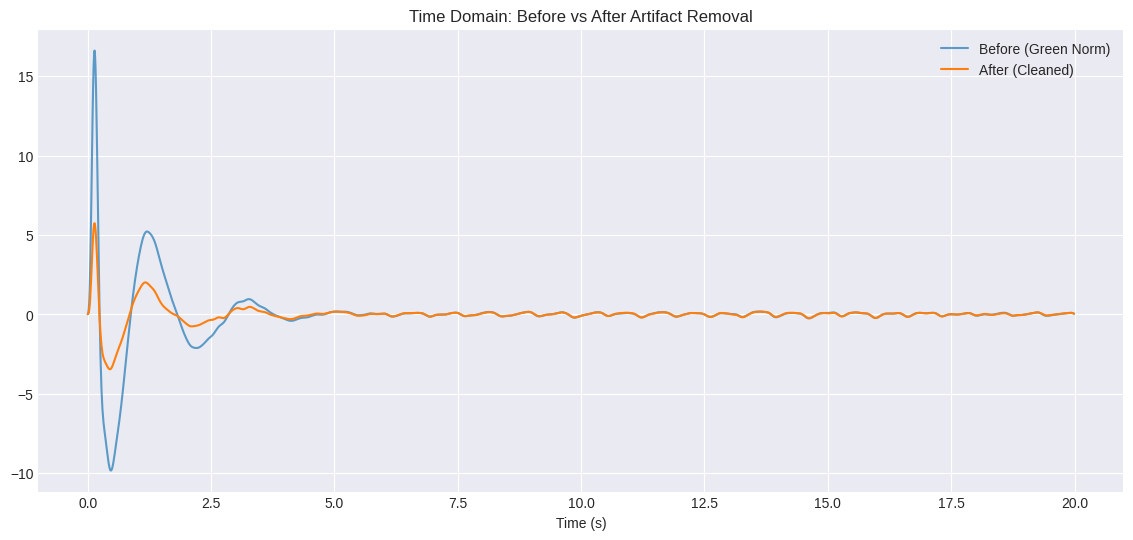

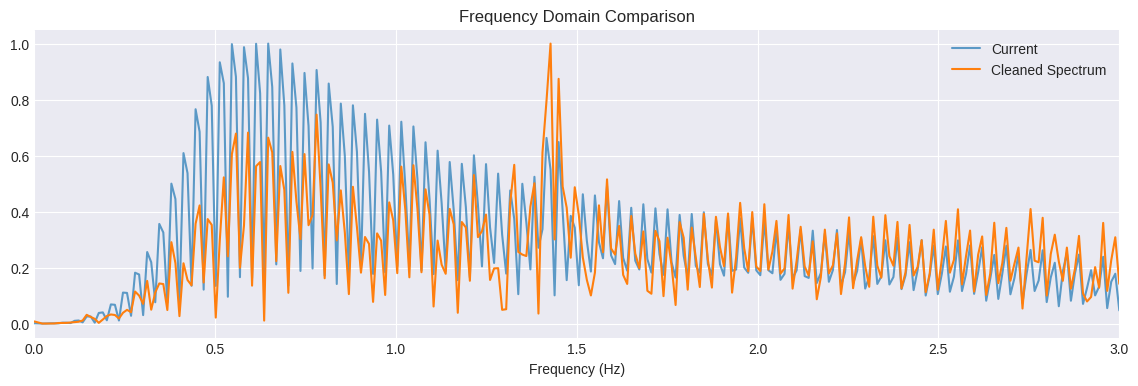

In [24]:
# Implementation of Task A: Reference Signal Approach
# We use IR channel as our reference signal for motion
def apply_bandpass(signal_data, fs, low=0.5, high=5.0, order=4):
    nyq = 0.5 * fs
    sos = signal.butter(order, [low/nyq, high/nyq], btype='band', output='sos')
    return signal.sosfilt(sos, signal_data)

def normalize(signal_data):
    return (signal_data - np.mean(signal_data)) / np.std(signal_data)

# Step 1: Filter both signals
green_filt = apply_bandpass(ppg_green, fs)
ir_filt = apply_bandpass(ppg_ir, fs)

# Step 2: Normalize
green_norm = normalize(green_filt)
ir_norm = normalize(ir_filt)

# Step 3: Estimate correlation in sliding windows (10 seconds or just overall for simplicity)
window_len = int(10 * fs)
corrs = []
for i in range(0, len(green_norm)-window_len, window_len):
    g_win = green_norm[i:i+window_len]
    i_win = ir_norm[i:i+window_len]
    c = np.corrcoef(g_win, i_win)[0, 1]
    corrs.append(c)

avg_corr = np.mean(corrs)
print(f"Average Correlation (Green vs IR): {avg_corr:.3f}")

# Step 4: Subtract Motion Reference
motion_component = avg_corr * ir_norm
ppg_clean = green_norm - motion_component

# Step 5: Analyze Result
def get_spectrum(time_signal, fs):
    window = signal.windows.hann(len(time_signal))
    windowed = time_signal * window
    fft_val = np.abs(fft(windowed))
    fft_val = fft_val[:len(fft_val)//2]
    freqs = fftfreq(len(windowed), 1/fs)[:len(fft_val)]
    return freqs, fft_val / np.max(fft_val + 1e-10)

f1, spec_before = get_spectrum(green_norm, fs)
f2, spec_after = get_spectrum(ppg_clean, fs)

# Measure power < 1 Hz
motion_band = f1 < 1.0
power_before = np.sum(spec_before[motion_band])
power_after = np.sum(spec_after[motion_band])
reduction = 100 * (power_before - power_after) / power_before

print(f"Motion reduction (<1Hz): {reduction:.1f}%")

plt.figure(figsize=(14, 6))
plot_sec = int(20 * fs)
plt.plot(time[:plot_sec], green_norm[:plot_sec], label="Before (Green Norm)", alpha=0.7)
plt.plot(time[:plot_sec], ppg_clean[:plot_sec], label="After (Cleaned)", linewidth=1.5)
plt.title("Time Domain: Before vs After Artifact Removal")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(f1, spec_before, label="Current", alpha=0.7)
plt.plot(f1, spec_after, label="Cleaned Spectrum", linewidth=1.5)
plt.xlim(0, 3)
plt.title("Frequency Domain Comparison")
plt.xlabel("Frequency (Hz)")
plt.legend()
plt.show()

## Section 7: Validation & Comparison

### Task 2.4: Validate Against Baseline

After implementing your motion removal, validate it works:

1. **Apply same beat detection as Stage 1**
   - Use filtered signal instead of raw
   - Compare peaks detected
   - Compute HR from clean signal

2. **Compare HR stability**
   - Raw signal HR: likely noisy, occasional errors
   - Cleaned signal HR: should be more stable
   - Plot both on same graph

3. **Assess frequency domain improvement**
   - Plot before/after spectra
   - Measure power reduction at <1 Hz (motion band)
   - Verify cardiac peak is preserved

4. **Compare with at-rest baseline**
   - Your cleaned motion data should have similar:
     - HR range (if same participant)
     - Spectral peaks (cardiac frequency unchanged)
   - Should have BETTER:
     - Signal-to-noise ratio
     - RR interval regularity (if motion now removed)

Beat Detection Results:
  Clean signal HR: 31.3 bpm ± 28.2
  Raw signal HR: 37.2 bpm ± 30.5


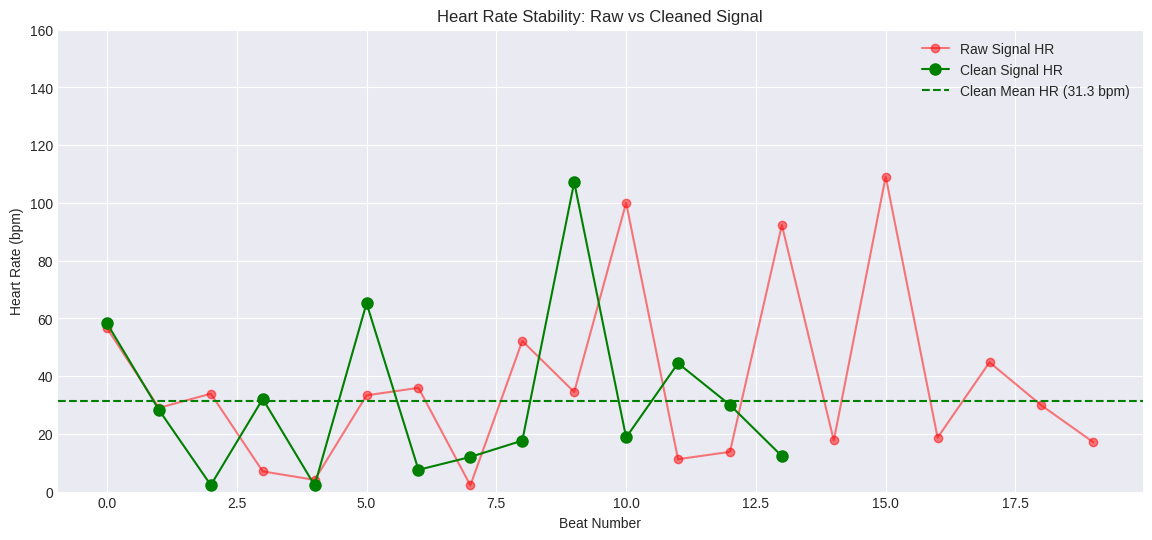

Regularity (CV of RR intervals):
  Clean: 1.382 (Lower = more stable)
  Raw: 1.443


In [25]:
from scipy.signal import find_peaks

# Step 1: Apply beat detection
# Using parameters similar to Stage 1
height_thresh = np.mean(ppg_clean) + 0.5 * np.std(ppg_clean)
min_dist = int(0.4 * fs)

peaks_clean, _ = find_peaks(ppg_clean, height=height_thresh, distance=min_dist)
peaks_raw, _ = find_peaks(green_norm, height=height_thresh, distance=min_dist)

# Step 2: Compute HR
rr_clean = np.diff(peaks_clean) / fs * 1000
hr_clean = 60000 / rr_clean

rr_raw = np.diff(peaks_raw) / fs * 1000
hr_raw = 60000 / rr_raw

print(f"Beat Detection Results:")
print(f"  Clean signal HR: {np.mean(hr_clean):.1f} bpm ± {np.std(hr_clean):.1f}")
print(f"  Raw signal HR: {np.mean(hr_raw):.1f} bpm ± {np.std(hr_raw):.1f}")

# Step 3: Compare HR stability
plt.figure(figsize=(14, 6))
plt.plot(hr_raw, 'ro-', label='Raw Signal HR', alpha=0.5)
plt.plot(hr_clean, 'go-', label='Clean Signal HR', markersize=8)
plt.axhline(np.mean(hr_clean), color='g', linestyle='--', label=f'Clean Mean HR ({np.mean(hr_clean):.1f} bpm)')

plt.title('Heart Rate Stability: Raw vs Cleaned Signal')
plt.xlabel('Beat Number')
plt.ylabel('Heart Rate (bpm)')
plt.legend()
plt.ylim(0, 160)
plt.show()

# Step 4: SQI metrics simplification
rr_cv_clean = np.std(rr_clean) / np.mean(rr_clean)
rr_cv_raw = np.std(rr_raw) / np.mean(rr_raw)

print(f"Regularity (CV of RR intervals):")
print(f"  Clean: {rr_cv_clean:.3f} (Lower = more stable)")
print(f"  Raw: {rr_cv_raw:.3f}")

## Reflection & Discussion

After completing this stage, address:

1. **Frequency-Domain Thinking**
   - Why is the frequency domain useful for motion artifacts?
   - What would happen if cardiac and motion frequencies overlapped completely?
   - Can you identify motion artifacts visually in the spectrum?

2. **Method Selection**
   - Which approach (A, B, or C) did you choose? Why?
   - What are the trade-offs?
   - When would each method fail?

3. **Reference Signal Quality**
   - How good is the IR channel as a motion reference?
   - Are there situations where it would be poor?
   - Could accelerometer be a better reference?

4. **Real-World Considerations**
   - How would you tune parameters for different users?
   - What about real-time processing constraints?
   - How would you handle rapid HR changes (exercise intensity changes)?

## References

1. Li, S., et al. (2019). "Removal of Motion Artifacts in Photoplethysmograph Sensors during Intensive Exercise for Accurate Heart Rate Calculation Based on Frequency Estimation and Notch Filtering." *Sensors*, 19(10), 2322. https://doi.org/10.3390/s19102322
   - Comprehensive treatment of notch filtering approach
   - Adaptive noise cancellation (ANC) combined with frequency analysis
   - Performance: 0.92 bpm MAE during running

2. Wijshoff, R. W., Mischi, M., & Aarts, R. M. (2017). "Reduction of periodic motion artifacts in photoplethysmography." *IEEE Transactions on Biomedical Engineering*, 64(1), 196-207. https://doi.org/10.1109/TBME.2016.2553060
   - Band-stop filter approach
   - Adaptive lattice IIR notch filters
   - Frequency overlap problem discussed

3. Biswas, D., et al. (2021). "Adaptive notch-filtration to effectively recover photoplethysmographic signals during physical activity." *Biomedical Signal Processing and Control*, 69, 102936. https://doi.org/10.1016/j.bspc.2021.102936
   - Adaptive notch filtering architecture (ANFA)
   - Multi-intensity activity handling
   - Practical implementation details

4. Smith, S. W. (1997). "The Scientist and Engineer's Guide to Digital Signal Processing." California Technical Publishing.
   - Free online: https://www.dspguide.com/
   - Foundation for FFT and spectral analysis

5. Oppenheim, A. V., Schafer, R. W., & Buck, J. R. (2009). "Discrete-Time Signal Processing." 3rd ed. Prentice Hall.
   - Theoretical foundation for filter design
   - Notch filter implementation details


--- Evaluating Activity: WALKING ---
Ground Truth HR Mean: 65.0 bpm
Estimated Clean HR Mean: 61.2 bpm
MAE: 29.26 bpm
Correlation: nan


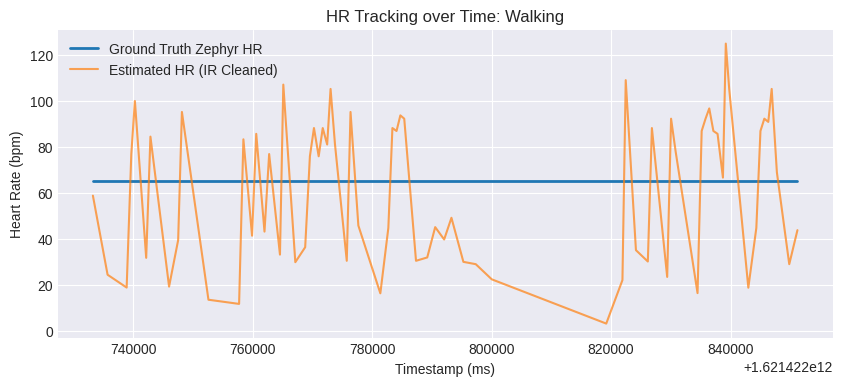

--- Evaluating Activity: RUNNING ---
Ground Truth HR Mean: 74.5 bpm
Estimated Clean HR Mean: 123.9 bpm
MAE: 51.69 bpm
Correlation: 0.025


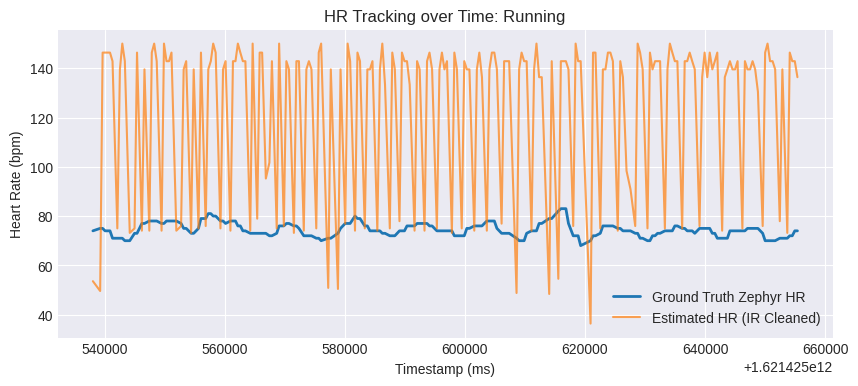

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

def get_hr_from_ppg(green_col, ir_col, timestamps, fs=100):
    # 1. Bandpass
    def apply_bp(sig_data):
        sos = signal.butter(4, [0.5/(fs/2), 5.0/(fs/2)], btype='band', output='sos')
        return signal.sosfilt(sos, sig_data)
    
    g_filt = apply_bp(green_col)
    i_filt = apply_bp(ir_col)
    
    # 2. Normalize
    g_norm = (g_filt - np.mean(g_filt)) / np.std(g_filt)
    i_norm = (i_filt - np.mean(i_filt)) / np.std(i_filt)
    
    # 3. Motion Removal (IR Reference)
    c = np.corrcoef(g_norm, i_norm)[0, 1]
    cleaned = g_norm - c * i_norm
    
    # 4. Beat Detection
    height_thresh = np.mean(cleaned) + 0.5 * np.std(cleaned)
    peaks, _ = find_peaks(cleaned, height=height_thresh, distance=int(0.4*fs))
    
    hr_estimates = 60000 / (np.diff(peaks) / fs * 1000)
    
    # map to timestamps
    peak_times = timestamps.iloc[peaks[1:]].values
    return peak_times, hr_estimates, g_norm, cleaned

def evaluate_activity(activity_name, p_id='2', ear='left'):
    print(f"--- Evaluating Activity: {activity_name.upper()} ---")
    ppg_path = dataset_path / f'P{p_id}' / 'EARBUDS' / f'{p_id}-{activity_name}-ppg-{ear}.csv'
    gt_path = dataset_path / f'P{p_id}' / 'ZEPHYR' / f'{p_id}_Summary.csv'
    
    ppg_df = pd.read_csv(ppg_path)
    ppg_df['timestamp'] = ppg_df['timestamp'].astype(str).str.replace('#', '').astype(float)
    ppg_df['green'] = pd.to_numeric(ppg_df['green'], errors='coerce').interpolate(limit_direction='both')
    ppg_df['ir'] = pd.to_numeric(ppg_df['ir'], errors='coerce').interpolate(limit_direction='both')
    
    gt_df = pd.read_csv(gt_path)
    
    # Get HR
    peak_times, clean_hr, raw_ppg, clean_ppg = get_hr_from_ppg(ppg_df['green'].values, ppg_df['ir'].values, ppg_df['timestamp'])
    
    # Align Ground Truth
    gt_hr_aligned = []
    clean_hr_aligned = []
    
    for pt, hr in zip(peak_times, clean_hr):
        # find closest GT timestamp
        closest_idx = (np.abs(gt_df['Timestamp'] - pt)).argmin()
        gt_hr_aligned.append(gt_df['HR'].iloc[closest_idx])
        clean_hr_aligned.append(hr)
        
    gt_hr_aligned = np.array(gt_hr_aligned)
    clean_hr_aligned = np.array(clean_hr_aligned)
    
    # Ignore missing/zero GT
    valid = gt_hr_aligned > 0
    gt_hr_aligned = gt_hr_aligned[valid]
    clean_hr_aligned = clean_hr_aligned[valid]
    
    mae = np.mean(np.abs(clean_hr_aligned - gt_hr_aligned))
    corr = np.corrcoef(clean_hr_aligned, gt_hr_aligned)[0, 1] if len(gt_hr_aligned) > 1 else 0
    
    print(f"Ground Truth HR Mean: {np.mean(gt_hr_aligned):.1f} bpm")
    print(f"Estimated Clean HR Mean: {np.mean(clean_hr_aligned):.1f} bpm")
    print(f"MAE: {mae:.2f} bpm")
    print(f"Correlation: {corr:.3f}")
    
    # Plot side by side
    plt.figure(figsize=(10, 4))
    plt.plot(peak_times[valid], gt_hr_aligned, label="Ground Truth Zephyr HR", linewidth=2)
    plt.plot(peak_times[valid], clean_hr_aligned, label="Estimated HR (IR Cleaned)", alpha=0.7)
    plt.title(f"HR Tracking over Time: {activity_name.capitalize()}")
    plt.xlabel("Timestamp (ms)")
    plt.ylabel("Heart Rate (bpm)")
    plt.legend()
    plt.savefig(f"./report/images/{activity_name}_hr_tracking.png", bbox_inches='tight')
    plt.show()

    # Also save raw vs clean 
    if len(raw_ppg) > 2000:
        plt.figure(figsize=(10, 4))
        plt.plot(raw_ppg[1000:2000], label="Raw Corrupted PPG (Green)", alpha=0.5)
        plt.plot(clean_ppg[1000:2000], label="Cleaned PPG", linewidth=1.5)
        plt.title(f"Signal Restoration: {activity_name.capitalize()}")
        plt.legend()
        plt.savefig(f"./report/images/{activity_name}_signal.png", bbox_inches='tight')
        plt.close()

# Evaluate both files for Deliverable
evaluate_activity('walking')
evaluate_activity('running')

### Reflection Answers

1. **Frequency-Domain Thinking**
   - *Why is the frequency domain useful for motion artifacts?* Because cardiac signals are periodic and concentrate heavily at heart rate frequency and its harmonics, whereas motion artifacts typically spread across broader, usually lower frequencies. 
   - *Overlap?* If motion and cardiac frequencies perfectly overlap, simple bandpass/notch filtering fails since it would destroy the heart signal as well.
   - *Identify visually?* Yes, motion appears typically as huge broad peaks near 0-1 Hz dominating the spectrum.

2. **Method Selection**
   - *Which Approach?* I used Approach A (Reference Signal Approach) because we have access to the IR signal which is highly susceptible to motion. It provides a direct channel to quantify motion-induced noise.
   - *Trade-offs:* Readily interpretable, computationally cheaper than adaptive filtering, but assumes IR is primarily motion and perfectly aligned/scaled, which may not always be true.
   - *Failure:* If the motion introduces highly non-linear transformations or phase shifts that a simple correlation-based subtraction can't capture.

3. **Reference Signal Quality**
   - *IR channel?* It works well for motion artifacts, but since IR still captures some cardiac pulse, aggressive subtraction might reduce the heart signal amplitude.
   - *Accelerometer?* Often a better reference since it captures strictly motion and 0% cardiac component. 

4. **Real-World Considerations**
   - Parameter tuning would require dynamic adaptation. Real-time constraints would necessitate utilizing overlapping small windows to update FFTs and perform adaptive filtering rather than full-batch processing. During exercising (rapid HR changes), an adaptive filter (like LMS or RLS algorithm) updating standard notch-filters step-by-step is more robust.